### Preprocessing Features
We'll perform one-hot encoding for categorical features and standard scaling for numerical features.

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Load the dataset (originally from cell 701d3a3d)
df = pd.read_excel('/content/Employee_Attrition.xlsx')

# Separate target variable 'Attrition' from features (originally from cell 701d3a3d)
y = df['Attrition']
X = df.drop('Attrition', axis=1)

# Convert 'Attrition' (y) to numerical (0 and 1) (originally from cell 701d3a3d)
le = LabelEncoder()
y = le.fit_transform(y)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_scaled_numerical = scaler.fit_transform(X_encoded[numerical_cols])

# Combine scaled numerical and one-hot encoded categorical features
# First, ensure columns are aligned for combining
X_scaled_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols, index=X_encoded.index)
X_onehot_df = X_encoded.drop(columns=numerical_cols)
X_processed = pd.concat([X_scaled_df, X_onehot_df], axis=1)

# Define X_hybrid (the preprocessed features before adding cluster labels)
X_hybrid = X_processed.copy()

### Dimensionality Reduction (PCA) for Visualization
Apply PCA to create `X_pca` which will be used for visualizing clusters.

In [19]:
# Apply PCA for visualization, reducing to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Define X_scaled (the full preprocessed features for clustering)
X_scaled = X_processed.copy()

### Define Optimal Number of Clusters
As indicated in the notebook, `OPTIMAL_K` is set to 3.

In [20]:
# Define the optimal number of clusters
OPTIMAL_K = 3

print("All necessary variables (df, y, X_scaled, X_pca, OPTIMAL_K, X_hybrid) are now defined.")

All necessary variables (df, y, X_scaled, X_pca, OPTIMAL_K, X_hybrid) are now defined.


### 1. Data Verification
Let's start by verifying the structure of our dataset `df` and the target variable `y`.

In [21]:
import pandas as pd

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
df.info()

print("\nAttrition target variable distribution:")
display(pd.Series(y).value_counts())

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,'Life Sciences',1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,'Research Development',8,1,'Life Sciences',1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,'Research Development',2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,'Research Development',3,4,'Life Sciences',1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,'Research Development',2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int6

,count
0,1233
1,237


### 2. K-means Clustering
We have already preprocessed and scaled the data (`X_scaled`) and determined the optimal number of clusters (`OPTIMAL_K = 3`). We will now apply K-means clustering and visualize the results. The `cluster_labels` and `cluster_attrition` variables are already available from a previous run.

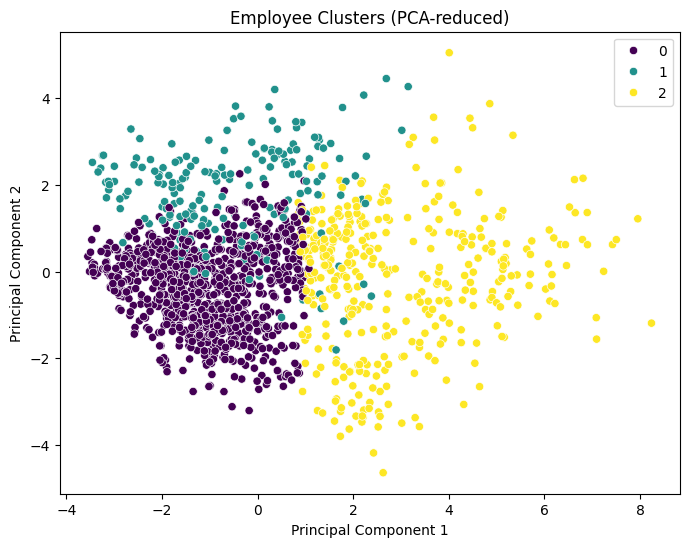


Attrition Rate per Cluster:


,Cluster,Attrition Rate
0,0,0.186874
1,1,0.185930
2,2,0.086022


/tmp/ipykernel_326/461845959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Attrition Rate', data=cluster_attrition, palette='coolwarm')


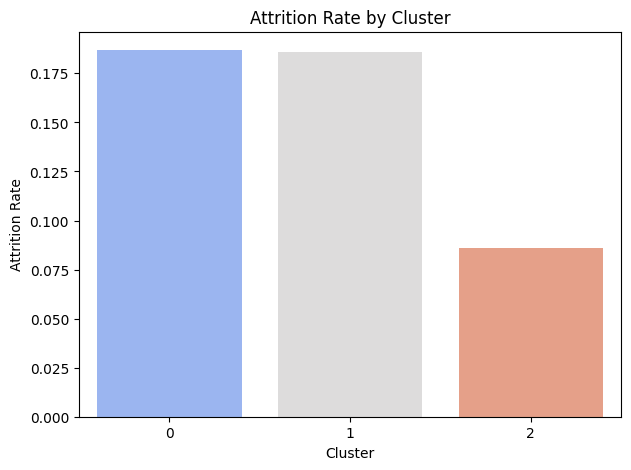

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Apply K-means using the optimal K (if not already run)
# If cluster_labels is not defined, run the following:
if 'cluster_labels' not in globals():
    kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

# Visualize clusters using PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', legend='full')
plt.title('Employee Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Display attrition rate per cluster (if not already run)
# If cluster_attrition is not defined, run the following:
if 'cluster_attrition' not in globals():
    temp_df = pd.DataFrame({'Cluster': cluster_labels, 'Attrition': y})
    cluster_attrition = temp_df.groupby('Cluster')['Attrition'].mean().reset_index()
    cluster_attrition.rename(columns={'Attrition': 'Attrition Rate'}, inplace=True)

print("\nAttrition Rate per Cluster:")
display(cluster_attrition)

plt.figure(figsize=(7, 5))
sns.barplot(x='Cluster', y='Attrition Rate', data=cluster_attrition, palette='coolwarm')
plt.title('Attrition Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Attrition Rate')
plt.show()

In [23]:
# import pandas as pd
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.decomposition import PCA

# # Load the dataset
# df = pd.read_excel('/content/IBM_Employee_Attrition_Dataset.xlsx')

# # Separate target variable 'Attrition' from features
# y = df['Attrition']
# X = df.drop('Attrition', axis=1)

# # Convert 'Attrition' (y) to numerical (0 and 1)
# le = LabelEncoder()
# y = le.fit_transform(y)

### 3. Hybrid Model: Random Forest with Cluster Feature
Now, we'll integrate the `cluster_labels` as a new feature into our dataset (`X_hybrid`) and train a Random Forest classifier to predict attrition.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Add cluster labels to the feature set X_hybrid
X_hybrid_with_clusters = X_hybrid.copy()
X_hybrid_with_clusters['Cluster'] = cluster_labels

# Split data into training and testing sets
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of training features:", X_train_hybrid.shape)
print("Shape of testing features:", X_test_hybrid.shape)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_hybrid = rf_model.predict(X_test_hybrid)
y_proba_hybrid = rf_model.predict_proba(X_test_hybrid)[:, 1]

print("\nRandom Forest Model Trained with Cluster Feature.")

Shape of training features: (1176, 48)
Shape of testing features: (294, 48)

Random Forest Model Trained with Cluster Feature.


### 4. Model Evaluation and Visualizations
Let's evaluate the performance of our hybrid Random Forest model and visualize its key metrics.

Accuracy: 0.8299

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



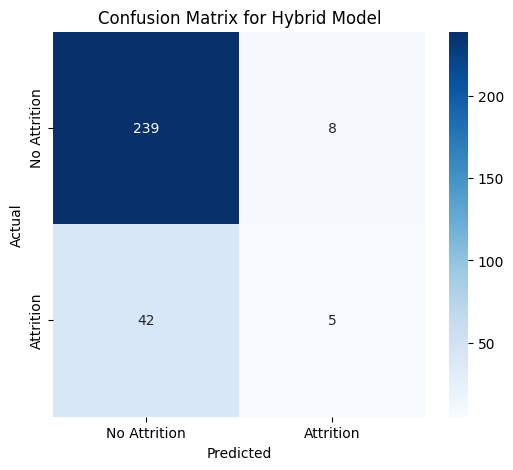

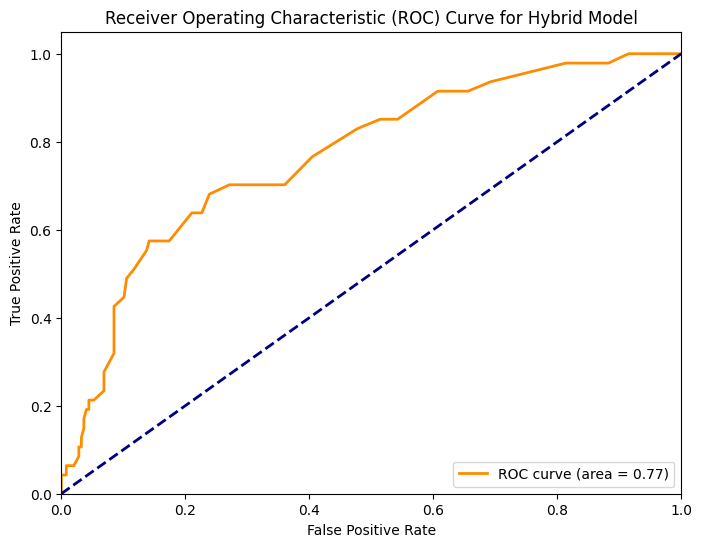

/tmp/ipykernel_326/502618223.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_hybrid.head(15), palette='magma')


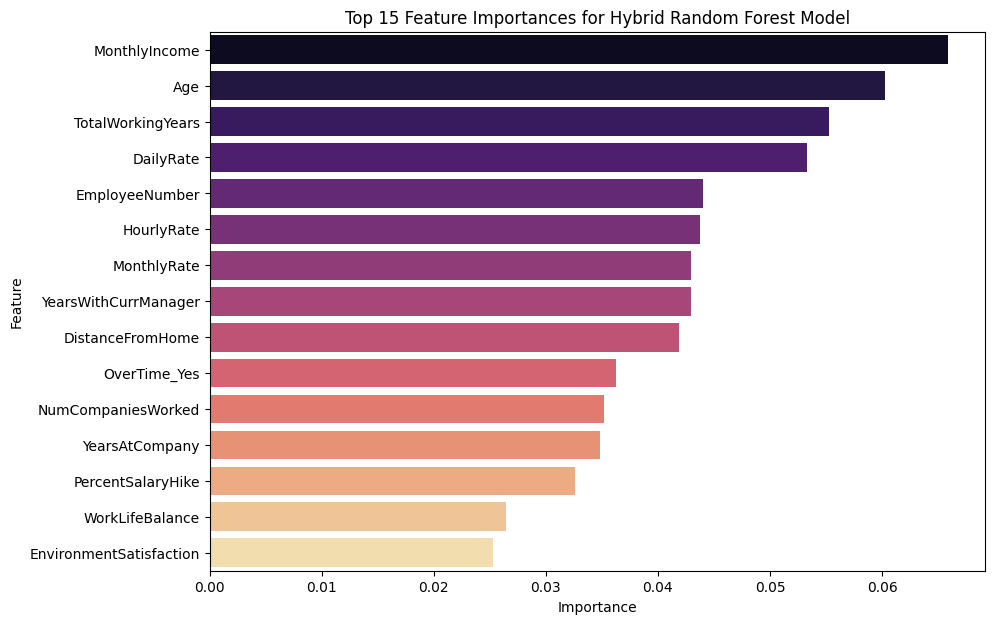

In [25]:
import numpy as np

# Evaluate the model
accuracy_hybrid = accuracy_score(y_test_hybrid, y_pred_hybrid)
print(f"Accuracy: {accuracy_hybrid:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_hybrid))

# Confusion Matrix
cm_hybrid = confusion_matrix(y_test_hybrid, y_pred_hybrid)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Hybrid Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test_hybrid, y_proba_hybrid)
roc_auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

plt.figure(figsize=(8, 6))
plt.plot(fpr_hybrid, tpr_hybrid, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_hybrid:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hybrid Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importances_hybrid = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_hybrid.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Hybrid Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 5. Individual Model Analysis: Logistic Regression
Let's analyze the Logistic Regression model in detail, including its performance metrics and visualizations.


--- Logistic Regression Model Evaluation ---
Accuracy: 0.8673

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       247
           1       0.67      0.34      0.45        47

    accuracy                           0.87       294
   macro avg       0.78      0.65      0.69       294
weighted avg       0.85      0.87      0.85       294



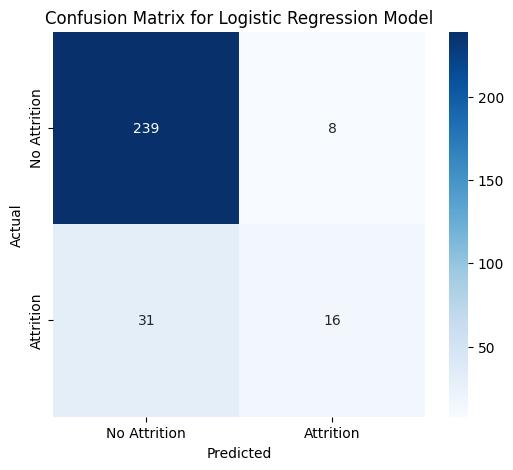

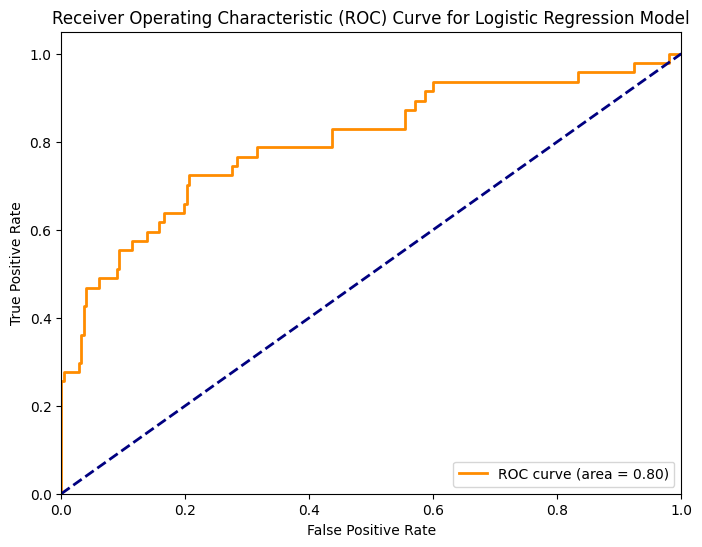

/tmp/ipykernel_326/1440824736.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_lr.head(15), palette='magma')


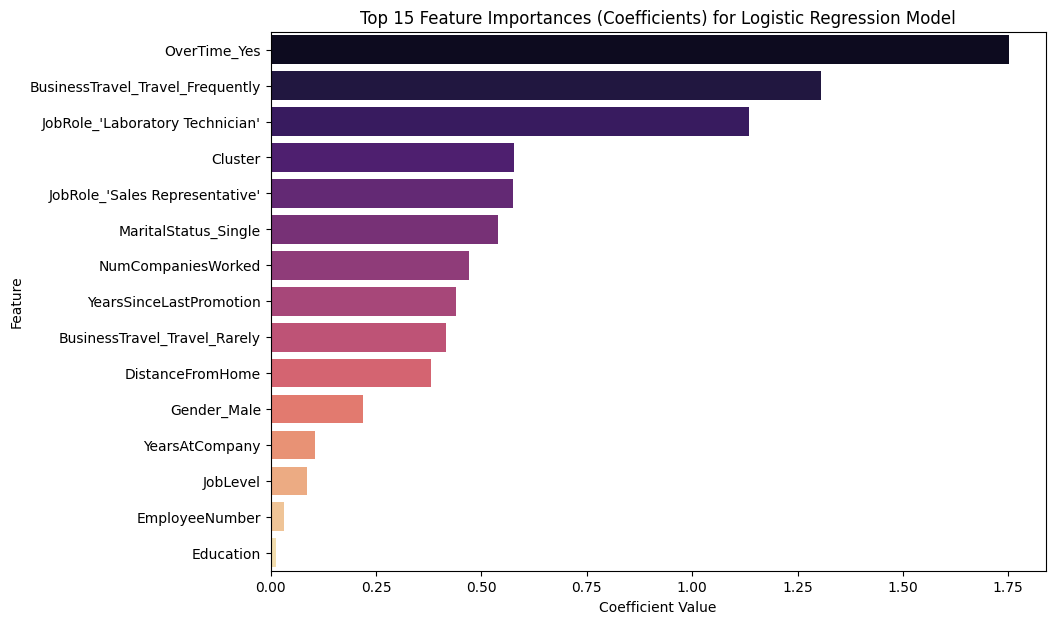

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data splits are available
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression Classifier
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
log_reg_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test_hybrid)
y_proba_lr = log_reg_model.predict_proba(X_test_hybrid)[:, 1]

print("\n--- Logistic Regression Model Evaluation ---")

# Evaluate the model
accuracy_lr = accuracy_score(y_test_hybrid, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test_hybrid, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_hybrid, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance (Coefficients for Logistic Regression)
feature_importances_lr = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': log_reg_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_lr.head(15), palette='magma')
plt.title('Top 15 Feature Importances (Coefficients) for Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

### 6. Individual Model Analysis: Decision Tree
Next, let's look at the Decision Tree Classifier, its performance, and feature importances.


--- Decision Tree Model Evaluation ---
Accuracy: 0.7891

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       247
           1       0.35      0.36      0.35        47

    accuracy                           0.79       294
   macro avg       0.61      0.62      0.61       294
weighted avg       0.79      0.79      0.79       294



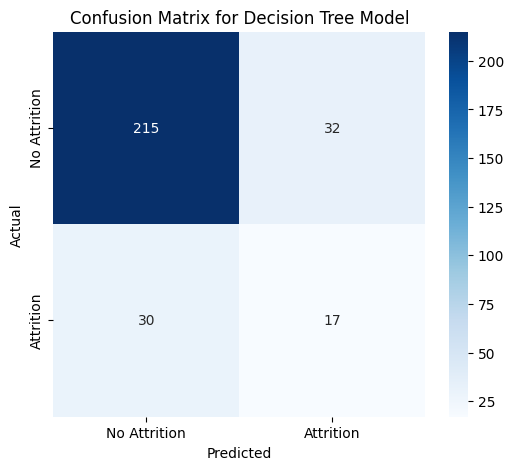

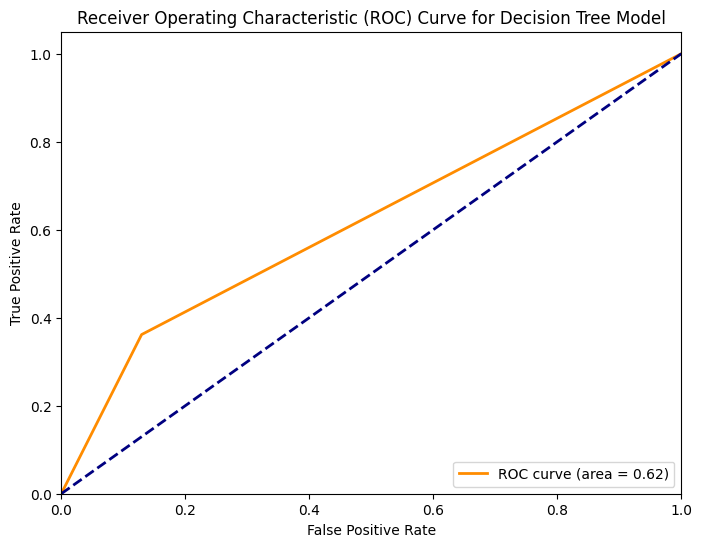

/tmp/ipykernel_326/204153038.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_dt.head(15), palette='magma')


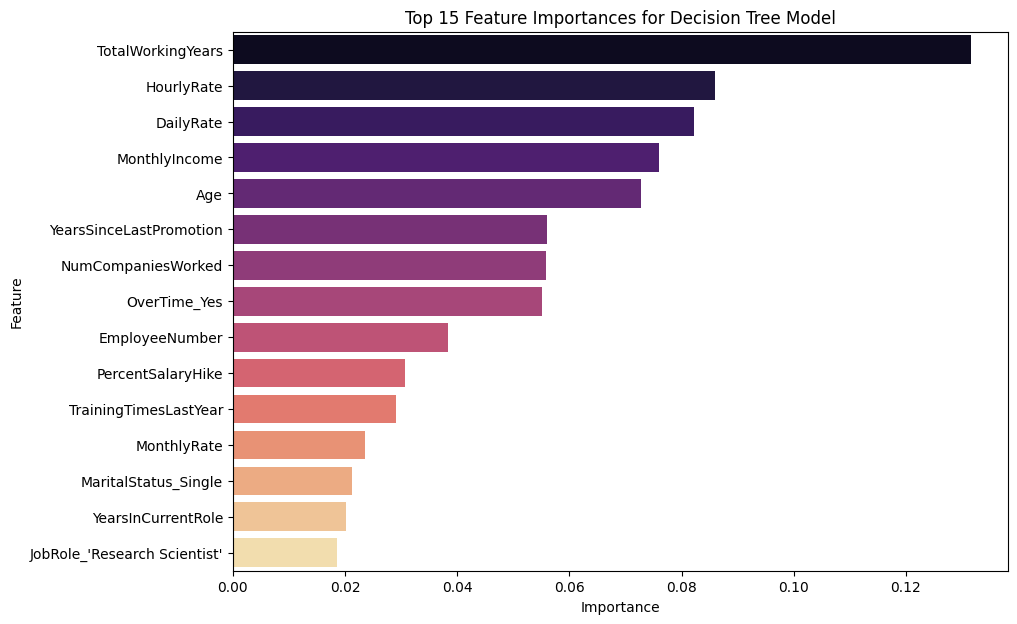

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data splits are available
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_dt = dt_model.predict(X_test_hybrid)
y_proba_dt = dt_model.predict_proba(X_test_hybrid)[:, 1]

print("\n--- Decision Tree Model Evaluation ---")

# Evaluate the model
accuracy_dt = accuracy_score(y_test_hybrid, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test_hybrid, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Decision Tree Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test_hybrid, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importances_dt = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_dt.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 7. Model Comparison: Logistic Regression, Decision Tree, and Random Forest
Let's compare the performance of Logistic Regression, Decision Tree, and Random Forest models on our dataset. We'll use the `X_hybrid_with_clusters` dataset, which includes the cluster labels as a feature.


--- Training Logistic Regression ---
Accuracy: 0.8673
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       247
           1       0.67      0.34      0.45        47

    accuracy                           0.87       294
   macro avg       0.78      0.65      0.69       294
weighted avg       0.85      0.87      0.85       294


--- Training Decision Tree ---
Accuracy: 0.7891
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       247
           1       0.35      0.36      0.35        47

    accuracy                           0.79       294
   macro avg       0.61      0.62      0.61       294
weighted avg       0.79      0.79      0.79       294


--- Training Random Forest ---
Accuracy: 0.8299
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1   

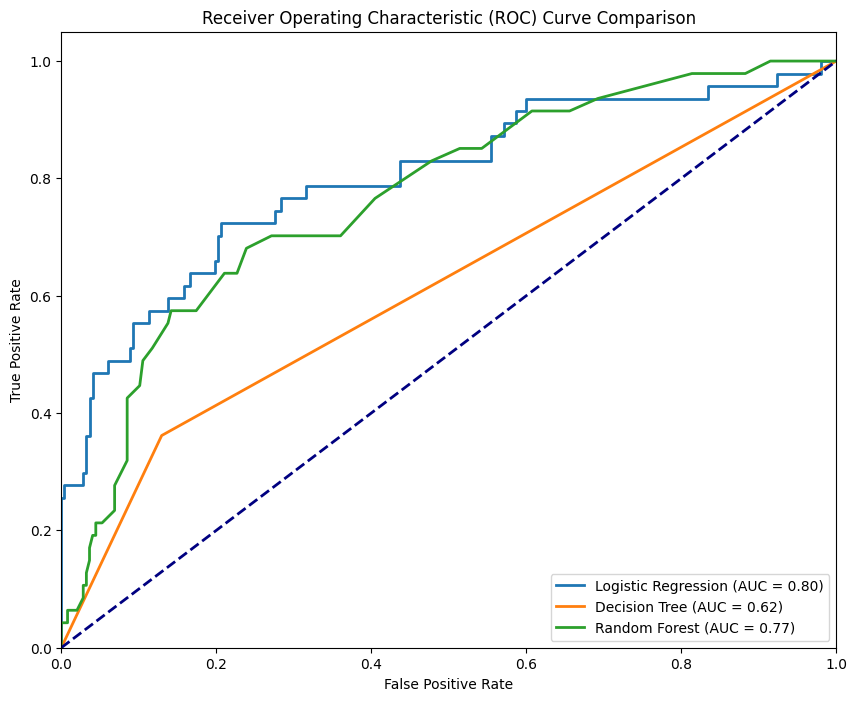


--- Summary of Model Performances ---
Logistic Regression:
  Accuracy: 0.8673
  AUC: 0.8002
  Precision (Attrition): 0.6667
  Recall (Attrition): 0.3404
Decision Tree:
  Accuracy: 0.7891
  AUC: 0.6161
  Precision (Attrition): 0.3469
  Recall (Attrition): 0.3617
Random Forest:
  Accuracy: 0.8299
  AUC: 0.7681
  Precision (Attrition): 0.3846
  Recall (Attrition): 0.1064


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming X_hybrid_with_clusters and y are already defined and split into train/test sets
# If not, ensure these are available from previous steps
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_hybrid, y_train_hybrid)
    y_pred = model.predict(X_test_hybrid)
    y_proba = model.predict_proba(X_test_hybrid)[:, 1]

    accuracy = accuracy_score(y_test_hybrid, y_pred)
    report = classification_report(y_test_hybrid, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test_hybrid, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'roc_auc': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_hybrid, y_pred))

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.show()

print("\n--- Summary of Model Performances ---")
for name, res in results.items():
    print(f"{name}:\n  Accuracy: {res['accuracy']:.4f}\n  AUC: {res['roc_auc']:.4f}")
    print(f"  Precision (Attrition): {res['classification_report']['1']['precision']:.4f}")
    print(f"  Recall (Attrition): {res['classification_report']['1']['recall']:.4f}")

### Conclusion: Model Performance for Attrition Prediction

To determine the 'best' method for predicting employee attrition, it's crucial to consider not just overall accuracy but also the specific business objective. For a company aiming to reduce attrition, accurately identifying employees likely to leave (high precision) and capturing as many of these individuals as possible (high recall) are key. The inherent class imbalance (fewer attriters than non-attriters) in the dataset also significantly impacts these metrics.

Let's recap the performance for the **Attrition (Class 1)**, where '1' represents attrition:

| Model                 | Accuracy | AUC      | Precision (Attrition) | Recall (Attrition) |
| :-------------------- | :------- | :------- | :-------------------- | :----------------- |
| **Logistic Regression** | 0.8673   | **0.8002** | **0.6667**            | 0.3404             |
| **Decision Tree**     | 0.7891   | 0.6161   | 0.3469                | 0.3617             |
| **Random Forest**     | 0.8299   | 0.7681   | 0.3846                | 0.1064             |

### Key Findings & Recommendation:

1.  **Overall Performance:** Among the three models, **Logistic Regression** demonstrates the most balanced performance and the highest Area Under the Curve (AUC) of 0.8002. This indicates its superior ability to distinguish between employees who will attrit and those who will not. Its precision for the attrition class (0.6667) suggests that when it predicts an employee will leave, it is relatively reliable.

2.  **Challenges with Recall:** A common challenge observed across all models is the **low recall for the attrition class**. Even the best model (Logistic Regression) only identifies about 34% of the employees who actually leave. The Random Forest model, while having decent overall accuracy and AUC, shows a particularly low recall (0.1064) for the attrition class, meaning it misses most of the actual attriters.

### Why Logistic Regression is Preferred:

Despite the low recall across the board, **Logistic Regression** stands out as the 'best' choice in this comparison due to:
*   **Highest AUC:** This provides the best overall measure of separability between the classes.
*   **Highest Precision for Attrition:** Its higher precision for the positive class makes its positive predictions more trustworthy, which is vital for targeted intervention strategies.

### Next Steps for Improvement:

To build a more effective attrition prediction system, further efforts should focus on:

*   **Addressing Class Imbalance:** Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or using class weights during model training could significantly improve the models' ability to detect the minority attrition class.
*   **Hyperparameter Tuning:** Fine-tuning the hyperparameters of the Logistic Regression model, or exploring other advanced ensemble methods (e.g., Gradient Boosting), could yield even better results.
*   **Feature Engineering:** Further analysis and creation of new, more predictive features from the existing dataset might uncover stronger signals for attrition.
*   **Advanced Models:** Investigating more complex models tailored for imbalanced datasets could be beneficial.

In summary, while Logistic Regression provides a strong initial foundation with more reliable predictions for identified attrition cases, future development should prioritize enhancing the model's recall to proactively identify a larger proportion of employees at risk of leaving.